In [20]:
import os 
import mediapipe as mp
import cv2
import matplotlib.pyplot as plt
import pickle 
import pandas as  pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,accuracy_score


In [26]:
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
hands = mp_hands.Hands(static_image_mode = True,
                       min_detection_confidence = 0.9)
hands

[INFO] Found 5996 image(s) in 'A'


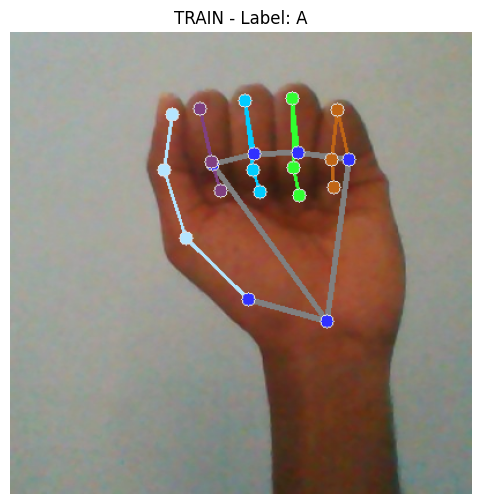

[INFO] Found 5996 image(s) in 'B'


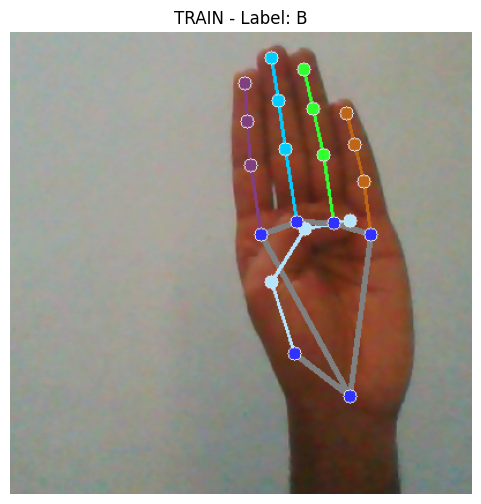

[INFO] Found 5996 image(s) in 'C'


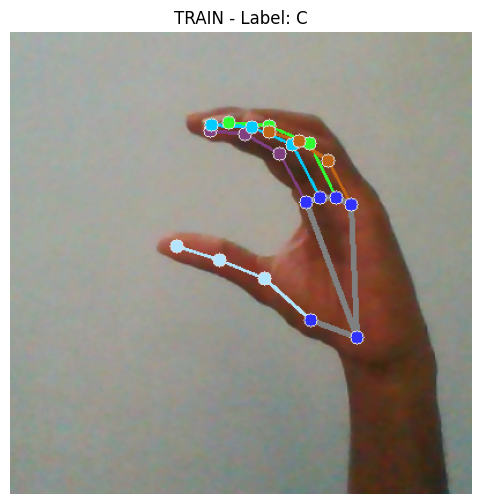

[INFO] Found 5996 image(s) in 'D'


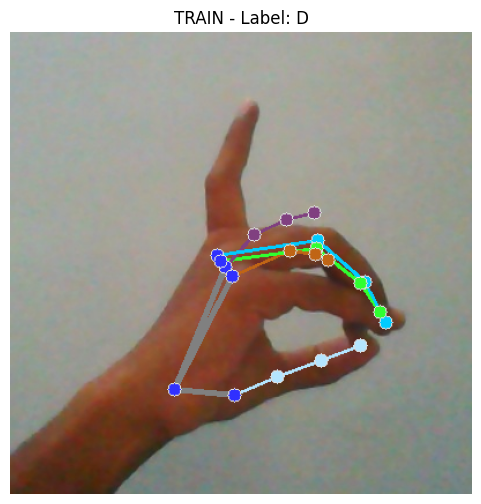

[INFO] Found 5996 image(s) in 'E'


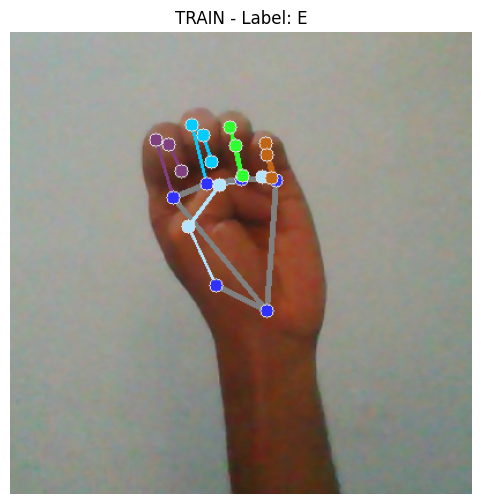

[INFO] Found 5996 image(s) in 'F'


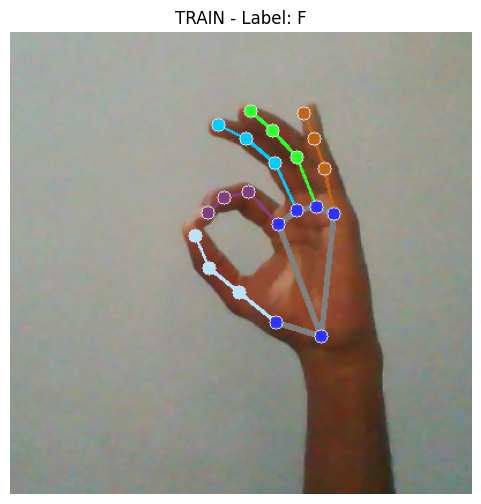

[INFO] Found 5996 image(s) in 'G'


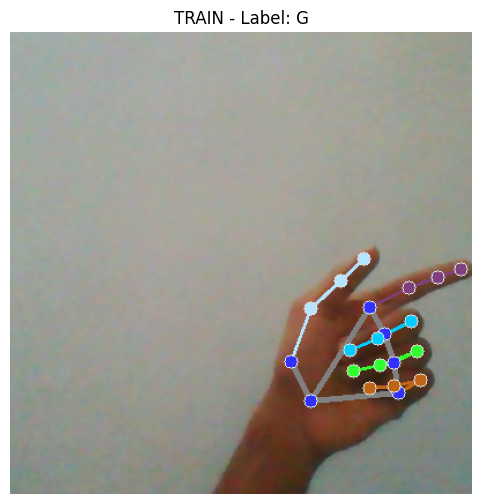

[INFO] Found 5996 image(s) in 'H'


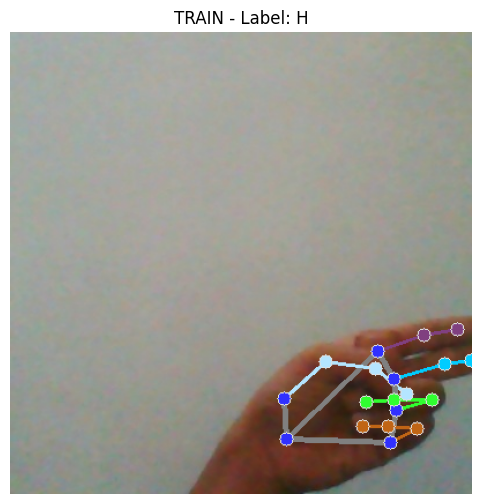

[INFO] Found 5996 image(s) in 'I'


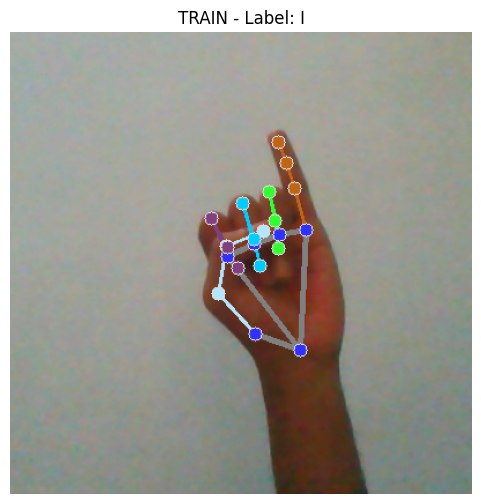

[INFO] Found 5996 image(s) in 'J'


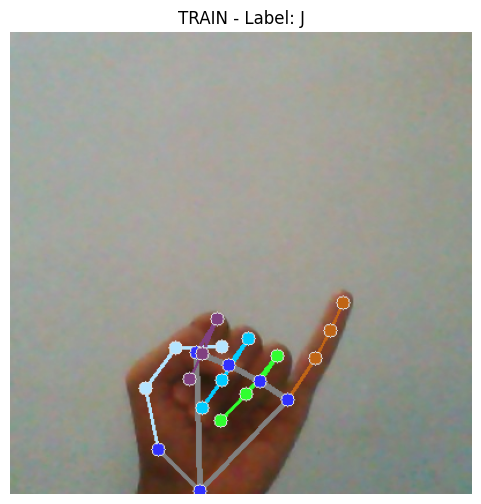

[INFO] Found 5996 image(s) in 'K'


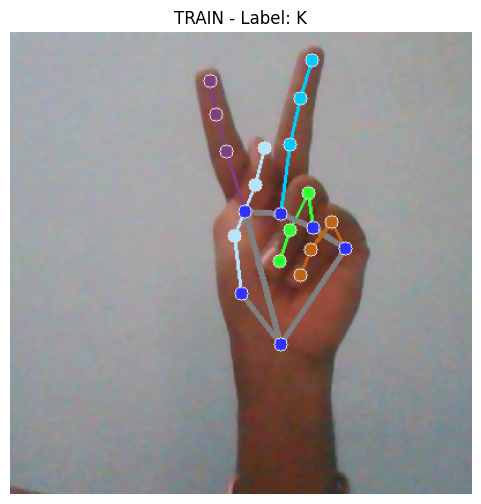

[INFO] Found 5996 image(s) in 'L'


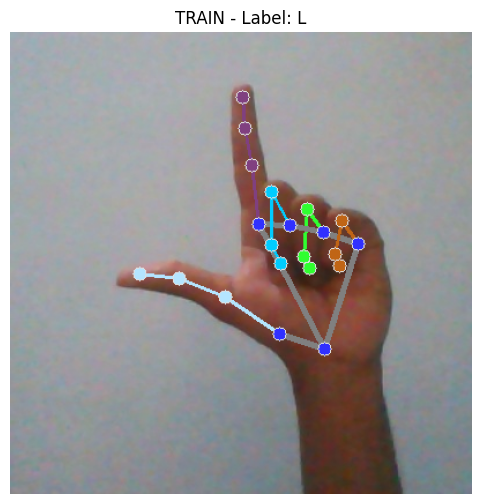

[INFO] Found 5996 image(s) in 'M'


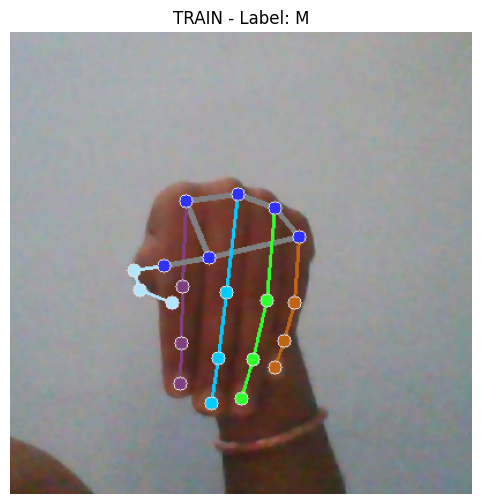

[INFO] Found 5996 image(s) in 'N'


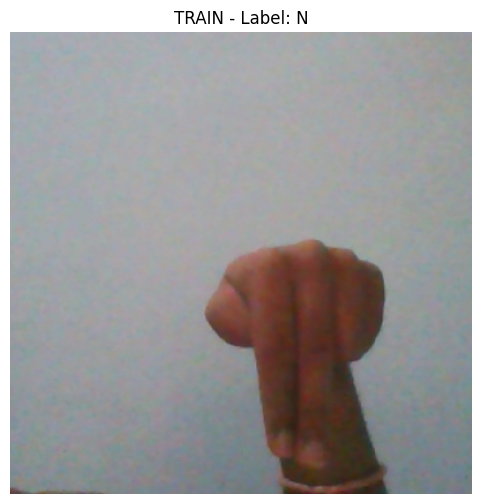

[INFO] Found 5996 image(s) in 'Nothing'


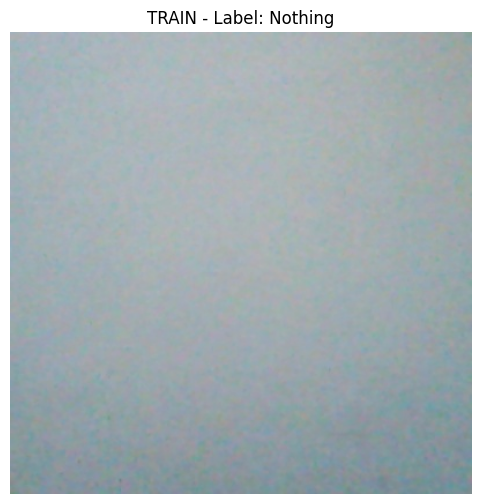

[INFO] Found 5996 image(s) in 'O'


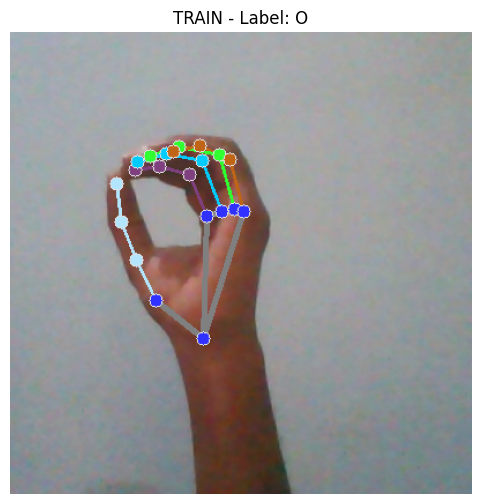

[INFO] Found 5996 image(s) in 'P'


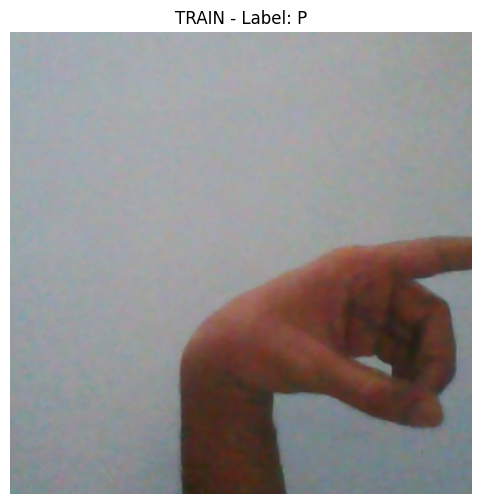

[INFO] Found 5996 image(s) in 'Q'


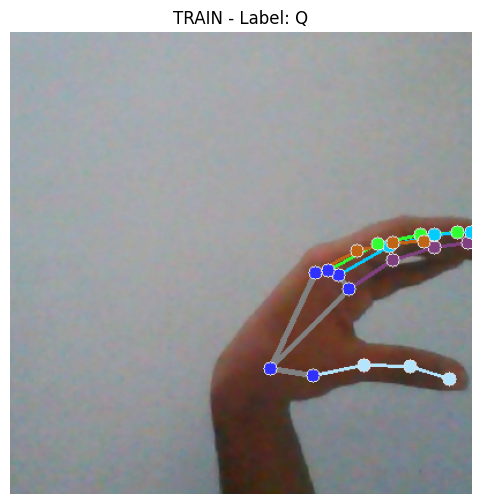

[INFO] Found 5966 image(s) in 'R'


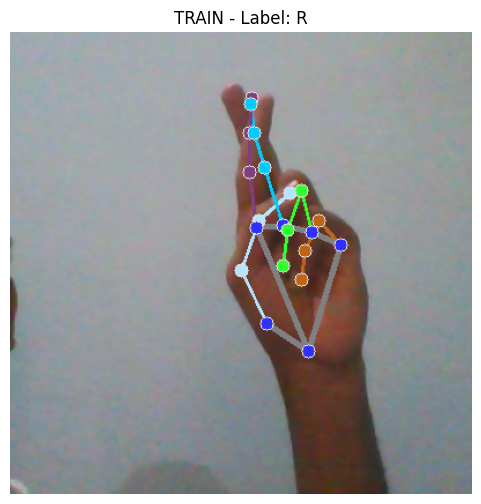

[INFO] Found 5996 image(s) in 'S'


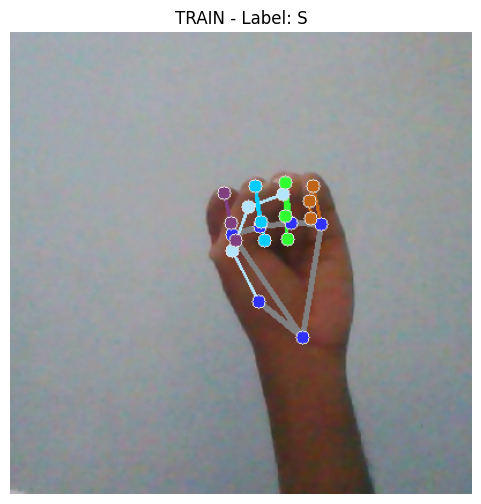

[INFO] Found 5886 image(s) in 'Space'


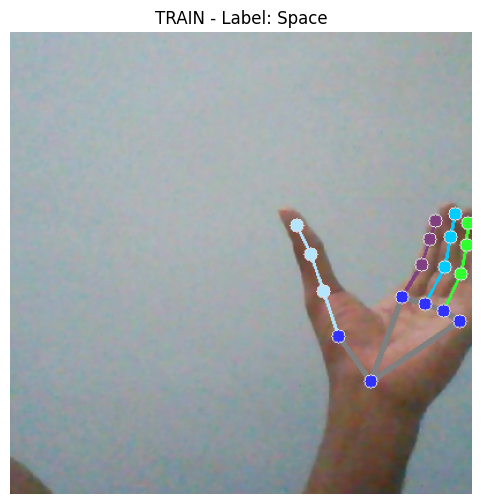

[INFO] Found 5648 image(s) in 'T'


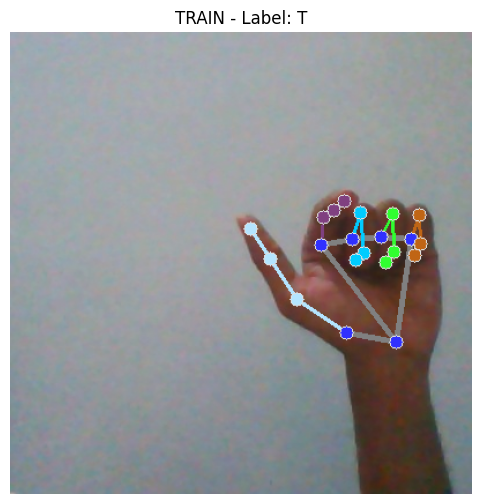

[INFO] Found 4542 image(s) in 'U'


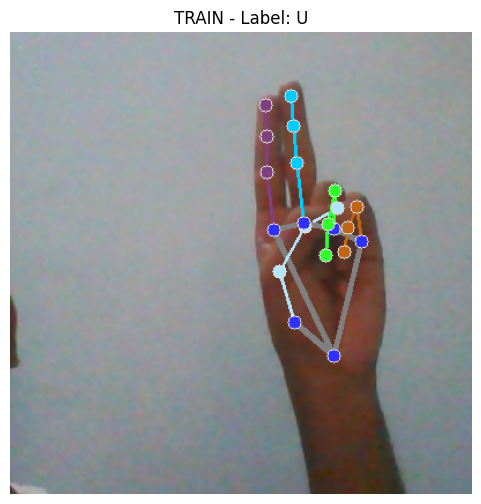

[INFO] Found 5996 image(s) in 'V'


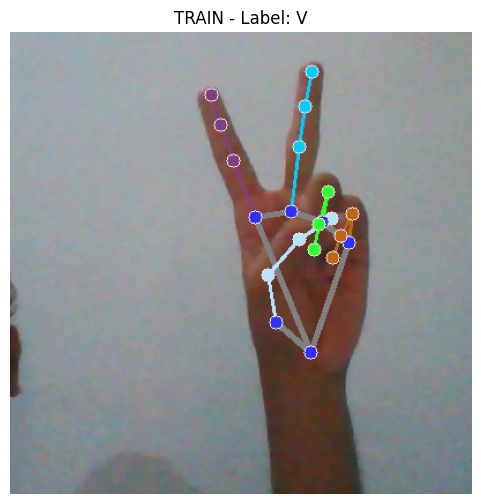

[INFO] Found 5996 image(s) in 'W'


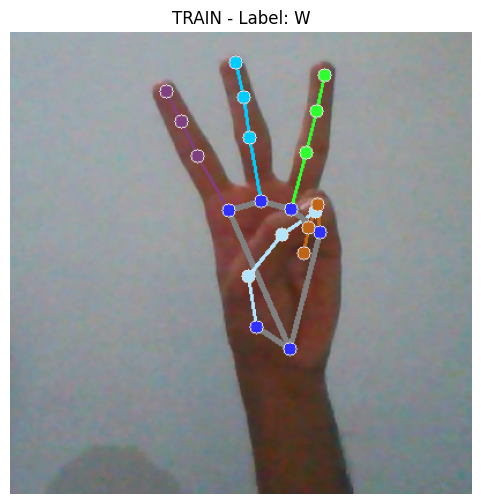

[INFO] Found 5996 image(s) in 'X'


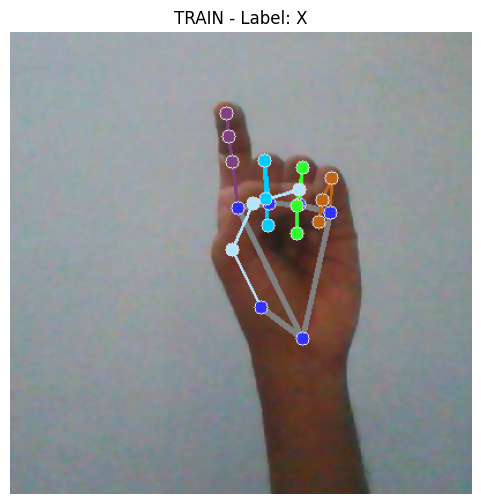

[INFO] Found 5720 image(s) in 'Y'


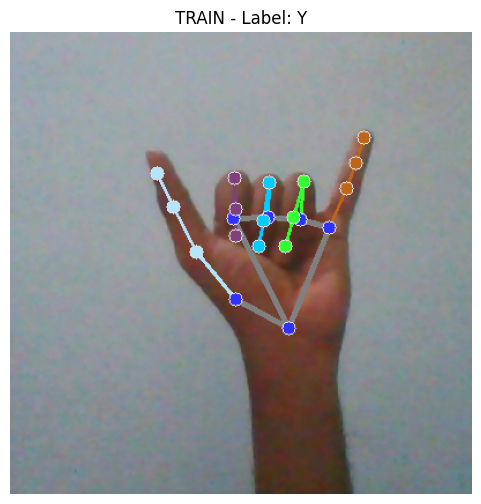

[INFO] Found 5996 image(s) in 'Z'


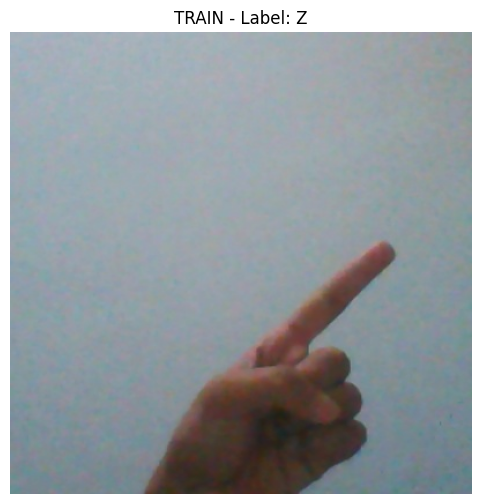

In [29]:
import os
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp

# Init MediaPipe
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
hands = mp_hands.Hands(static_image_mode=True)

# 📂 Path to your 'train' or 'test' folder
split = "Train"  # or "test"
data_dir = rf"C:\Users\jaikr\OneDrive\Desktop\1 MT 6TH\deep learning\CNN\ASL_WITHOUT_YOLO\Data\{split}"
valid_exts = [".jpg", ".jpeg", ".png"]

# 🔍 Loop through each class folder
for label in sorted(os.listdir(data_dir)):
    label_path = os.path.join(data_dir, label)

    if not os.path.isdir(label_path):
        continue

    # Only get image files
    image_files = [
        f for f in os.listdir(label_path)
        if os.path.isfile(os.path.join(label_path, f)) and os.path.splitext(f)[1].lower() in valid_exts
    ]

    print(f"[INFO] Found {len(image_files)} image(s) in '{label}'")

    if not image_files:
        continue

    # Load and visualize the first image in this label folder
    img_path = os.path.join(label_path, image_files[0])
    img = cv2.imread(img_path)

    if img is None:
        print(f"[WARNING] Could not read image: {img_path}")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)

    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                img_rgb,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,
                mp_drawing_styles.get_default_hand_landmarks_style(),
                mp_drawing_styles.get_default_hand_connections_style()
            )

    plt.figure(figsize=(6, 6))
    plt.title(f"{split.upper()} - Label: {label}")
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()


In [27]:
data

[]

In [23]:
# data_dir = "Data"
# data = []
# labels = []

# for i in sorted(os.listdir(data_dir)):
#     if i == ".DS_Store":
#         pass
#     else:
#         for j in os.listdir(os.path.join(data_dir,i)):
#             dat_aux = []
#             img = cv2.imread(os.path.join(data_dir,i,j))
#             img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
#             results = hands.process(img_rgb)
#             if results.multi_hand_landmarks:
#                 for hand_landmarks in results.multi_hand_landmarks:
#                     for z in range(len(hand_landmarks.landmark)):
#                         x = hand_landmarks.landmark[z].x
#                         y = hand_landmarks.landmark[z].y
#                         dat_aux.append(x)
#                         dat_aux.append(y)
#                 data.append(dat_aux)
#                 labels.append(i)

# ##save data 
# f = open("data.pkl","wb")
# pickle.dump(data,f)
# f.close()


In [ ]:
# # ##visualsie data

# # data_dir = "Data"
# # for i in sorted(os.listdir(data_dir)):
# #     if i == ".DS_Store":
# #         pass
# #     else:
# #         for j in os.listdir(os.path.join(data_dir,i))[0:1]:
# #             img = cv2.imread(os.path.join(data_dir,i,j))
# #             img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
# #             results = hands.process(img_rgb)
# #             if results.multi_hand_landmarks:
# #                 for hand_landmarks in results.multi_hand_landmarks:
# #                     mp_drawing.draw_landmarks(
# #                         img_rgb,
# #                         hand_landmarks,
# #                         mp_hands.HAND_CONNECTIONS,
# #                         mp_drawing_styles.get_default_hand_landmarks_style(),
# #                         mp_drawing_styles.get_default_hand_connections_style())
# #                 plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
# #                 plt.show()



# import os
# import cv2
# import matplotlib.pyplot as plt
# import mediapipe as mp

# # Initialize MediaPipe components
# mp_hands = mp.solutions.hands
# mp_drawing = mp.solutions.drawing_utils
# mp_drawing_styles = mp.solutions.drawing_styles

# hands = mp_hands.Hands(static_image_mode=True)  # Good for single images

# data_dir = "Data"

# # Loop through one image per label for visualization
# for label in sorted(os.listdir(data_dir)):
#     if label == ".DS_Store":
#         continue

#     label_path = os.path.join(data_dir, label)
#     image_files = [f for f in os.listdir(label_path) if os.path.isfile(os.path.join(label_path, f))]

#     if not image_files:
#         continue

#     img_path = os.path.join(label_path, image_files[0])
#     img = cv2.imread(img_path)

#     if img is None:
#         print(f"[WARNING] Could not load image: {img_path}")
#         continue

#     img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     results = hands.process(img_rgb)

#     if results.multi_hand_landmarks:
#         for hand_landmarks in results.multi_hand_landmarks:
#             mp_drawing.draw_landmarks(
#                 img_rgb,
#                 hand_landmarks,
#                 mp_hands.HAND_CONNECTIONS,
#                 mp_drawing_styles.get_default_hand_landmarks_style(),
#                 mp_drawing_styles.get_default_hand_connections_style()
#             )

#     # Show the image using matplotlib
#     plt.figure(figsize=(6, 6))
#     plt.title(f"Label: {label}")
#     plt.imshow(img_rgb)
#     plt.axis('off')
#     plt.show()


In [ ]:
import os
import cv2
import pickle
import mediapipe as mp

# Init MediaPipe
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True)

# Set to 'train' or 'test'
split = "Train"
data_dir = rf"C:\Users\jaikr\OneDrive\Desktop\1 MT 6TH\deep learning\CNN\ASL_WITHOUT_YOLO\Data\{split}"
valid_exts = [".jpg", ".jpeg", ".png"]

data = []
labels = []

# Loop through each label (A, B, C...)
for label in sorted(os.listdir(data_dir)):
    label_path = os.path.join(data_dir, label)
    if not os.path.isdir(label_path):
        continue

    image_files = [
        f for f in os.listdir(label_path)
        if os.path.isfile(os.path.join(label_path, f)) and os.path.splitext(f)[1].lower() in valid_exts
    ]

    print(f"[INFO] Processing {len(image_files)} images in '{label}'")

    for image_name in image_files:
        img_path = os.path.join(label_path, image_name)
        img = cv2.imread(img_path)

        if img is None:
            print(f"[WARNING] Failed to load image: {img_path}")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = hands.process(img_rgb)

        # Extract landmarks
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                dat_aux = []
                for lm in hand_landmarks.landmark:
                    dat_aux.append(lm.x)
                    dat_aux.append(lm.y)

                data.append(dat_aux)
                labels.append(label)

print(f"[✅] Done! Total samples collected: {len(data)}")

# Save data
with open("data.pkl", "wb") as f:
    pickle.dump((data, labels), f)

print("[💾] Saved landmark data and labels to 'data.pkl'")


[INFO] Processing 5996 images in 'A'


In [25]:
##training 
##split data 
x_train,x_test,y_train,y_test = train_test_split(
    np.array(data),labels,
    test_size=0.15,random_state=22,
    shuffle=True
)
##train 
model = RandomForestClassifier(random_state=22)
model.fit(x_train,y_train)
##predict 
pred = model.predict(x_test)
##accuracy
score = accuracy_score(y_test,pred)
print(score)

ValueError: With n_samples=0, test_size=0.15 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
##save the model 
f = open("model.pkl","wb")
pickle.dump(model,f)
f.close()

In [ ]:
##detection 
model_dict = pickle.load(open("model.pkl","rb"))
model = model_dict["model"]

In [ ]:
cap = cv2.VideoCapture(0)

with mp_hands.Hands(min_detection_confidence=0.8,
                    min_tracking_confidence=0.8) as hands:
    while cap.isOpened():
        data_aux = []
        x_ = []
        y_ = []

        ret,frame = cap.read()
        H,W , _ = frame.shape

        frame_rgb = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
        frame_rgb = cv2.flip(frame_rgb,1)
        frame_rgb.flags.writeable = False
        results = hands.process(frame_rgb)
        frame_rgb.flags.writeable = True
        frame_rgb = cv2.cvtColor(frame_rgb,cv2.COLOR_BGR2RGB)
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                mp_drawing.draw_landmarks(
                    frame_rgb,
                    hand_landmarks,
                    mp_hands.HAND_CONNECTIONS,
                    mp_drawing.DrawingSpec(color=(28,255,3),thickness=5,
                                           circle_radius = 10 ),
                    mp_drawing.DrawingSpec(color=(236,255,3),thickness=5,
                                           circle_radius = 10 ) 
                )
            for hand_landmarks in results.multi_hand_landmarks:
                for i in range(len(hand_landmarks.landmark)):
                    x = hand_landmarks.landmark[i].x
                    y =hand_landmarks.landmark[i].y
                    data_aux.append(x)
                    data_aux.append(y)
                    x_.append(x)
                    y_.append(y)

            x1 = int(min(x_)* W) - 10
            y1 = int(min(y_)* H) - 10

            x2 = int(max(x_)*W) - 10 
            y2 = int(max(y_)*H) - 10 

            prediction = model.predict([np.array(data_aux)[0:42]])[0]
            cv2.rectangle(frame_rgb,(x1,y1-10),(x2,y2),(255,99,173),6)
            cv2.putText(frame_rgb,prediction,(x1,y1),cv2.FONT_HERSHEY_DUPLEX,
                        5,(255,0,0),5,cv2.LINE_AA)
            cv2.imshow("frame",frame_rgb)
            ##cv2.waitkey(1)

            if cv2.waitKey(10) & 0xFF ==ord("q"):
                break
cap.release()
cv2.destroyAllWindows()